<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/architectures/transformers/experiment_transformer_from_scratch_gpt_full_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# TRANSFORMER FROM SCRATCH (STEP-BY-STEP)
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================================================
# 1. SELF-ATTENTION (CORE IDEA OF TRANSFORMER)
# =========================================================
class SelfAttention(nn.Module):
    def __init__(self, embed_size):
        super().__init__()

        # embed_size = size of each word vector
        self.embed_size = embed_size

        # These layers convert input into:
        # Query (Q), Key (K), Value (V)
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys   = nn.Linear(embed_size, embed_size, bias=False)
        self.queries= nn.Linear(embed_size, embed_size, bias=False)

    def forward(self, x):
        """
        x shape: (batch_size, sequence_length, embed_size)

        Example:
        batch_size = 4
        sequence_length = 10 words
        embed_size = 32
        """

        # Step 1: Create Q, K, V
        V = self.values(x)   # What information each word carries
        K = self.keys(x)     # What each word is related to
        Q = self.queries(x)  # What we are looking for

        # Step 2: Compute attention scores
        # Q * K^T → tells how much each word attends to others
        energy = torch.bmm(Q, K.transpose(1, 2))
        # shape: (batch, seq_len, seq_len)

        # Step 3: Scale the values (important for stability)
        scale = self.embed_size ** (1/2)

        # Step 4: Convert to probabilities
        attention = torch.softmax(energy / scale, dim=-1)

        # Step 5: Multiply attention with values
        out = torch.bmm(attention, V)

        return out


# =========================================================
# 2. MULTI-HEAD ATTENTION
# =========================================================
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()

        self.embed_size = embed_size
        self.heads = heads

        # Each head gets part of embedding
        self.head_dim = embed_size // heads

        # One attention per head
        self.attention = SelfAttention(self.head_dim)

        # Final layer to combine all heads
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        batch_size, seq_len, embed_size = x.shape

        # Step 1: Split embedding into multiple heads
        x = x.view(batch_size, seq_len, self.heads, self.head_dim)

        # Rearrange: (batch, heads, seq_len, head_dim)
        x = x.permute(0, 2, 1, 3)

        outputs = []

        # Step 2: Apply attention to each head
        for i in range(self.heads):
            out = self.attention(x[:, i])
            outputs.append(out)

        # Step 3: Concatenate all heads
        out = torch.cat(outputs, dim=-1)

        # Step 4: Final linear layer
        return self.fc_out(out)


# =========================================================
# 3. FEED FORWARD NETWORK
# =========================================================
class FeedForward(nn.Module):
    def __init__(self, embed_size):
        super().__init__()

        # Expands → learns → compresses
        self.fc1 = nn.Linear(embed_size, embed_size * 4)
        self.fc2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


# =========================================================
# 4. TRANSFORMER BLOCK
# =========================================================
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()

        self.attention = MultiHeadAttention(embed_size, heads)

        # Layer normalization (stabilizes training)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.feed_forward = FeedForward(embed_size)

    def forward(self, x):
        # Step 1: Self-attention
        attention = self.attention(x)

        # Step 2: Add residual connection
        x = self.norm1(attention + x)

        # Step 3: Feed forward
        forward = self.feed_forward(x)

        # Step 4: Another residual
        out = self.norm2(forward + x)

        return out


# =========================================================
# 5. SIMPLE TRANSFORMER MODEL
# =========================================================
class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size, embed_size, heads, num_classes):
        super().__init__()

        # Convert word indices → vectors
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # One transformer block
        self.transformer = TransformerBlock(embed_size, heads)

        # Final classification layer
        self.fc = nn.Linear(embed_size, num_classes)

    def forward(self, x):
        """
        x: (batch_size, sequence_length)
        """

        # Step 1: Convert words to embeddings
        x = self.embedding(x)

        # Step 2: Pass through transformer
        x = self.transformer(x)

        # Step 3: Pooling (average over sequence)
        x = x.mean(dim=1)

        # Step 4: Classification
        return self.fc(x)


# =========================================================
# 6. TEST WITH DUMMY DATA
# =========================================================

vocab_size = 100
seq_len = 10
batch_size = 4

# Random input (simulating sentences)
x = torch.randint(0, vocab_size, (batch_size, seq_len))

# Random labels (0 or 1)
y = torch.randint(0, 2, (batch_size,))


# =========================================================
# 7. TRAINING LOOP
# =========================================================

model = SimpleTransformer(
    vocab_size=vocab_size,
    embed_size=32,
    heads=4,
    num_classes=2
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(5):
    optimizer.zero_grad()

    outputs = model(x)
    loss = loss_fn(outputs, y)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.7501
Epoch 2, Loss: 0.6956
Epoch 3, Loss: 0.6467
Epoch 4, Loss: 0.6033
Epoch 5, Loss: 0.5653


In [2]:
# ============================================
# TRANSFORMER FROM SCRATCH (LEVEL 2)
# ============================================

import torch
import torch.nn as nn
import math

# =========================================================
# 1. POSITIONAL ENCODING (CRITICAL CONCEPT)
# =========================================================
class PositionalEncoding(nn.Module):
    def __init__(self, embed_size, max_len=5000):
        super().__init__()

        """
        Transformers have NO sense of order.
        So we manually add position information.

        Idea:
        Each position gets a unique pattern using sin/cos.
        """

        pe = torch.zeros(max_len, embed_size)

        for pos in range(max_len):
            for i in range(0, embed_size, 2):
                pe[pos][i] = math.sin(pos / (10000 ** (i / embed_size)))
                pe[pos][i+1] = math.cos(pos / (10000 ** (i / embed_size)))

        # shape: (1, max_len, embed_size)
        pe = pe.unsqueeze(0)

        # Register buffer → not trainable
        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        x: (batch, seq_len, embed_size)
        """
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]


# =========================================================
# 2. MULTI-HEAD SELF-ATTENTION (PROPER VERSION)
# =========================================================
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()

        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        # Linear layers for Q, K, V
        self.values = nn.Linear(embed_size, embed_size)
        self.keys   = nn.Linear(embed_size, embed_size)
        self.queries= nn.Linear(embed_size, embed_size)

        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        batch_size, seq_len, embed_size = x.shape

        # Step 1: Get Q, K, V
        V = self.values(x)
        K = self.keys(x)
        Q = self.queries(x)

        # Step 2: Split into heads
        V = V.view(batch_size, seq_len, self.heads, self.head_dim)
        K = K.view(batch_size, seq_len, self.heads, self.head_dim)
        Q = Q.view(batch_size, seq_len, self.heads, self.head_dim)

        # Rearrange for computation
        V = V.permute(0, 2, 1, 3)
        K = K.permute(0, 2, 1, 3)
        Q = Q.permute(0, 2, 1, 3)

        # Step 3: Attention calculation
        energy = torch.matmul(Q, K.transpose(-1, -2))

        # Scale
        attention = torch.softmax(energy / math.sqrt(self.head_dim), dim=-1)

        # Step 4: Apply attention to values
        out = torch.matmul(attention, V)

        # Step 5: Combine heads
        out = out.permute(0, 2, 1, 3).contiguous()
        out = out.view(batch_size, seq_len, embed_size)

        return self.fc_out(out)


# =========================================================
# 3. FEED FORWARD NETWORK
# =========================================================
class FeedForward(nn.Module):
    def __init__(self, embed_size):
        super().__init__()

        self.fc1 = nn.Linear(embed_size, embed_size * 4)
        self.fc2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))


# =========================================================
# 4. TRANSFORMER BLOCK (FULL VERSION)
# =========================================================
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout):
        super().__init__()

        self.attention = MultiHeadAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.feed_forward = FeedForward(embed_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Attention + residual
        attn = self.attention(x)
        x = self.norm1(x + self.dropout(attn))

        # Feed forward + residual
        forward = self.feed_forward(x)
        x = self.norm2(x + self.dropout(forward))

        return x


# =========================================================
# 5. FULL TRANSFORMER ENCODER
# =========================================================
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, heads, num_layers, num_classes, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_encoding = PositionalEncoding(embed_size)

        # Stack multiple transformer blocks
        self.layers = nn.ModuleList([
            TransformerBlock(embed_size, heads, dropout)
            for _ in range(num_layers)
        ])

        self.fc = nn.Linear(embed_size, num_classes)

    def forward(self, x):
        # Step 1: Word embedding
        x = self.embedding(x)

        # Step 2: Add position info
        x = self.pos_encoding(x)

        # Step 3: Pass through stacked layers
        for layer in self.layers:
            x = layer(x)

        # Step 4: Pooling (average)
        x = x.mean(dim=1)

        # Step 5: Classification
        return self.fc(x)


# =========================================================
# 6. TEST WITH DUMMY DATA
# =========================================================

vocab_size = 100
seq_len = 12
batch_size = 4

x = torch.randint(0, vocab_size, (batch_size, seq_len))
y = torch.randint(0, 2, (batch_size,))

# =========================================================
# 7. TRAINING
# =========================================================

model = TransformerEncoder(
    vocab_size=vocab_size,
    embed_size=64,
    heads=4,
    num_layers=2,
    num_classes=2
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(5):
    optimizer.zero_grad()

    output = model(x)
    loss = loss_fn(output, y)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.9550
Epoch 2, Loss: 0.3837
Epoch 3, Loss: 0.1476
Epoch 4, Loss: 0.0619
Epoch 5, Loss: 0.0302


In [3]:
# ============================================
# TRANSFORMER FROM SCRATCH (LEVEL 3)
# Encoder + Decoder + Masking (Advanced)
# ============================================

import torch
import torch.nn as nn
import math

# =========================================================
# 1. POSITIONAL ENCODING
# =========================================================
class PositionalEncoding(nn.Module):
    def __init__(self, embed_size, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, embed_size)

        for pos in range(max_len):
            for i in range(0, embed_size, 2):
                pe[pos][i] = math.sin(pos / (10000 ** (i / embed_size)))
                pe[pos][i+1] = math.cos(pos / (10000 ** (i / embed_size)))

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# =========================================================
# 2. MULTI-HEAD ATTENTION WITH MASKING
# =========================================================
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()

        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        self.values = nn.Linear(embed_size, embed_size)
        self.keys   = nn.Linear(embed_size, embed_size)
        self.queries= nn.Linear(embed_size, embed_size)

        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query, mask=None):
        batch_size = query.shape[0]

        # Create Q, K, V
        V = self.values(values)
        K = self.keys(keys)
        Q = self.queries(query)

        # Split into heads
        V = V.view(batch_size, -1, self.heads, self.head_dim).permute(0,2,1,3)
        K = K.view(batch_size, -1, self.heads, self.head_dim).permute(0,2,1,3)
        Q = Q.view(batch_size, -1, self.heads, self.head_dim).permute(0,2,1,3)

        # Compute attention
        energy = torch.matmul(Q, K.transpose(-1, -2))

        # 🔥 APPLY MASK HERE
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy / math.sqrt(self.head_dim), dim=-1)

        out = torch.matmul(attention, V)

        # Combine heads
        out = out.permute(0,2,1,3).contiguous()
        out = out.view(batch_size, -1, self.embed_size)

        return self.fc_out(out)


# =========================================================
# 3. FEED FORWARD
# =========================================================
class FeedForward(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        self.fc1 = nn.Linear(embed_size, embed_size * 4)
        self.fc2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))


# =========================================================
# 4. ENCODER BLOCK
# =========================================================
class EncoderBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout):
        super().__init__()

        self.attention = MultiHeadAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.ff = FeedForward(embed_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn))

        forward = self.ff(x)
        x = self.norm2(x + self.dropout(forward))

        return x


# =========================================================
# 5. DECODER BLOCK (WITH CROSS ATTENTION)
# =========================================================
class DecoderBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout):
        super().__init__()

        self.self_attention = MultiHeadAttention(embed_size, heads)
        self.cross_attention = MultiHeadAttention(embed_size, heads)

        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.norm3 = nn.LayerNorm(embed_size)

        self.ff = FeedForward(embed_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, tgt_mask):
        # Step 1: Masked self-attention (GPT-style)
        attn = self.self_attention(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn))

        # Step 2: Cross-attention (look at encoder output)
        attn2 = self.cross_attention(enc_out, enc_out, x, src_mask)
        x = self.norm2(x + self.dropout(attn2))

        # Step 3: Feed forward
        forward = self.ff(x)
        x = self.norm3(x + self.dropout(forward))

        return x


# =========================================================
# 6. FULL TRANSFORMER
# =========================================================
class Transformer(nn.Module):
    def __init__(self, vocab_size, embed_size, heads, num_layers):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos = PositionalEncoding(embed_size)

        self.encoder = nn.ModuleList([
            EncoderBlock(embed_size, heads, dropout=0.1)
            for _ in range(num_layers)
        ])

        self.decoder = nn.ModuleList([
            DecoderBlock(embed_size, heads, dropout=0.1)
            for _ in range(num_layers)
        ])

        self.fc = nn.Linear(embed_size, vocab_size)

    def forward(self, src, tgt, src_mask, tgt_mask):
        # Encoder
        enc = self.embedding(src)
        enc = self.pos(enc)

        for layer in self.encoder:
            enc = layer(enc, src_mask)

        # Decoder
        dec = self.embedding(tgt)
        dec = self.pos(dec)

        for layer in self.decoder:
            dec = layer(dec, enc, src_mask, tgt_mask)

        return self.fc(dec)


# =========================================================
# 7. CREATE MASKS
# =========================================================
def create_mask(seq):
    return (seq != 0).unsqueeze(1).unsqueeze(2)

def create_tgt_mask(seq_len):
    return torch.tril(torch.ones((seq_len, seq_len))).bool()


# =========================================================
# 8. TEST
# =========================================================
vocab_size = 100
batch_size = 2
seq_len = 6

src = torch.randint(1, vocab_size, (batch_size, seq_len))
tgt = torch.randint(1, vocab_size, (batch_size, seq_len))

src_mask = create_mask(src)
tgt_mask = create_tgt_mask(seq_len)

model = Transformer(vocab_size, embed_size=64, heads=4, num_layers=2)

out = model(src, tgt, src_mask, tgt_mask)

print("Output shape:", out.shape)

Output shape: torch.Size([2, 6, 100])


In [4]:
# ============================================
# GPT-LIKE TRANSFORMER (FINAL LEVEL)
# Decoder-only + causal masking
# ============================================

import torch
import torch.nn as nn
import math

# =========================================================
# 1. LEARNABLE POSITIONAL EMBEDDING (LIKE GPT)
# =========================================================
class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, embed_size):
        super().__init__()

        # Instead of sin/cos → learn positions
        self.pos_embed = nn.Embedding(max_len, embed_size)

    def forward(self, x):
        batch_size, seq_len = x.shape

        positions = torch.arange(0, seq_len).unsqueeze(0).repeat(batch_size, 1)
        return self.pos_embed(positions)


# =========================================================
# 2. MULTI-HEAD ATTENTION (CAUSAL MASKING)
# =========================================================
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()

        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        self.qkv = nn.Linear(embed_size, embed_size * 3)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, x, mask):
        batch_size, seq_len, embed_size = x.shape

        # Get Q, K, V together
        qkv = self.qkv(x)
        qkv = qkv.view(batch_size, seq_len, 3, self.heads, self.head_dim)

        Q, K, V = qkv[:,:,0], qkv[:,:,1], qkv[:,:,2]

        Q = Q.permute(0,2,1,3)
        K = K.permute(0,2,1,3)
        V = V.permute(0,2,1,3)

        # Attention
        energy = torch.matmul(Q, K.transpose(-1, -2))

        # 🔥 CAUSAL MASK (future blocked)
        energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy / math.sqrt(self.head_dim), dim=-1)

        out = torch.matmul(attention, V)

        # Combine heads
        out = out.permute(0,2,1,3).contiguous()
        out = out.view(batch_size, seq_len, embed_size)

        return self.fc_out(out)


# =========================================================
# 3. TRANSFORMER BLOCK
# =========================================================
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()

        self.attn = MultiHeadAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)

        self.ff = nn.Sequential(
            nn.Linear(embed_size, embed_size*4),
            nn.GELU(),  # GPT uses GELU (better than ReLU)
            nn.Linear(embed_size*4, embed_size)
        )

        self.norm2 = nn.LayerNorm(embed_size)

    def forward(self, x, mask):
        attn = self.attn(x, mask)
        x = self.norm1(x + attn)

        ff = self.ff(x)
        x = self.norm2(x + ff)

        return x


# =========================================================
# 4. GPT MODEL
# =========================================================
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, embed_size, heads, num_layers, max_len):
        super().__init__()

        self.token_embed = nn.Embedding(vocab_size, embed_size)
        self.pos_embed = PositionalEmbedding(max_len, embed_size)

        self.layers = nn.ModuleList([
            TransformerBlock(embed_size, heads)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(embed_size)

        # 🔥 Weight sharing trick (used in GPT)
        self.fc_out = nn.Linear(embed_size, vocab_size)
        self.fc_out.weight = self.token_embed.weight

    def forward(self, x, mask):
        token = self.token_embed(x)
        pos = self.pos_embed(x)

        x = token + pos

        for layer in self.layers:
            x = layer(x, mask)

        x = self.norm(x)

        return self.fc_out(x)


# =========================================================
# 5. CAUSAL MASK
# =========================================================
def create_causal_mask(seq_len):
    return torch.tril(torch.ones(seq_len, seq_len)).bool()


# =========================================================
# 6. DUMMY DATA (NEXT WORD PREDICTION)
# =========================================================
vocab_size = 50
seq_len = 8
batch_size = 2

data = torch.randint(1, vocab_size, (batch_size, seq_len))

# Input = everything except last token
x = data[:, :-1]

# Target = everything except first token
y = data[:, 1:]

mask = create_causal_mask(seq_len-1)

# =========================================================
# 7. TRAINING
# =========================================================
model = MiniGPT(
    vocab_size=vocab_size,
    embed_size=64,
    heads=4,
    num_layers=2,
    max_len=100
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(5):
    optimizer.zero_grad()

    output = model(x, mask)

    # reshape for loss
    output = output.reshape(-1, vocab_size)
    y_flat = y.reshape(-1)

    loss = loss_fn(output, y_flat)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 41.8317
Epoch 2, Loss: 35.1070
Epoch 3, Loss: 28.4159
Epoch 4, Loss: 22.1472
Epoch 5, Loss: 16.8373


In [6]:
# ============================================
# MINI GPT (FINAL LEVEL - PRODUCTION STYLE)
# Training + Generation + Full Pipeline
# ============================================

import torch
import torch.nn as nn
import math
import random

# =========================================================
# 1. SIMPLE TOKENIZER (CHAR LEVEL)
# =========================================================
text = "hello world this is a simple transformer model"

chars = sorted(list(set(text)))
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for ch,i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(l):
    return "".join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)

# =========================================================
# 2. CREATE TRAINING DATA
# =========================================================
block_size = 8

def get_batch(data, batch_size=4):
    x_batch, y_batch = [], []

    for _ in range(batch_size):
        idx = random.randint(0, len(data)-block_size-1)
        x = data[idx:idx+block_size]
        y = data[idx+1:idx+block_size+1]

        x_batch.append(x)
        y_batch.append(y)

    return torch.stack(x_batch), torch.stack(y_batch)


# =========================================================
# 3. MODEL COMPONENTS
# =========================================================
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()

        self.heads = heads
        self.head_dim = embed_size // heads

        self.qkv = nn.Linear(embed_size, embed_size*3)
        self.fc = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.qkv(x).view(B, T, 3, self.heads, self.head_dim)
        Q, K, V = qkv[:,:,0], qkv[:,:,1], qkv[:,:,2]

        Q = Q.permute(0,2,1,3)
        K = K.permute(0,2,1,3)
        V = V.permute(0,2,1,3)

        # Causal mask
        mask = torch.tril(torch.ones(T, T)).to(x.device)

        energy = torch.matmul(Q, K.transpose(-1,-2))
        energy = energy.masked_fill(mask==0, float("-1e20"))

        attn = torch.softmax(energy / math.sqrt(self.head_dim), dim=-1)

        out = torch.matmul(attn, V)

        out = out.permute(0,2,1,3).contiguous().view(B, T, C)

        return self.fc(out)


class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()

        self.attn = MultiHeadAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)

        self.ff = nn.Sequential(
            nn.Linear(embed_size, embed_size*4),
            nn.GELU(),
            nn.Linear(embed_size*4, embed_size)
        )

        self.norm2 = nn.LayerNorm(embed_size)

    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ff(x))
        return x


# =========================================================
# 4. GPT MODEL
# =========================================================
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, embed_size=64, heads=4, layers=2, block_size=8):
        super().__init__()

        self.token_embed = nn.Embedding(vocab_size, embed_size)
        self.pos_embed = nn.Embedding(block_size, embed_size)

        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_size, heads)
            for _ in range(layers)
        ])

        self.norm = nn.LayerNorm(embed_size)
        self.fc = nn.Linear(embed_size, vocab_size)

    def forward(self, x, targets=None):
        B, T = x.shape

        token = self.token_embed(x)
        pos = self.pos_embed(torch.arange(T))

        x = token + pos

        x = self.blocks(x)
        x = self.norm(x)

        logits = self.fc(x)

        loss = None
        if targets is not None:
            logits = logits.view(-1, logits.size(-1))
            targets = targets.view(-1)
            loss = nn.CrossEntropyLoss()(logits, targets)

        return logits, loss

    # =====================================================
    # 5. TEXT GENERATION (🔥 MOST IMPORTANT)
    # =====================================================
    def generate(self, x, max_new_tokens=20, temperature=1.0):
      for _ in range(max_new_tokens):

          # 🔥 IMPORTANT FIX
          x_cond = x[:, -self.pos_embed.num_embeddings:]

          logits, _ = self(x_cond)

          logits = logits[:, -1, :] / temperature
          probs = torch.softmax(logits, dim=-1)

          next_token = torch.multinomial(probs, num_samples=1)

          x = torch.cat((x, next_token), dim=1)

      return x


# =========================================================
# 6. TRAINING
# =========================================================
model = MiniGPT(vocab_size=len(chars))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for step in range(200):
    xb, yb = get_batch(data)

    _, loss = model(xb, yb)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")


# =========================================================
# 7. GENERATE TEXT
# =========================================================
start = torch.tensor([[stoi['h']]])

generated = model.generate(start, max_new_tokens=30)

print("\nGenerated Text:")
print(decode(generated[0].tolist()))

Step 0, Loss: 2.8987
Step 50, Loss: 0.9765
Step 100, Loss: 0.3433
Step 150, Loss: 0.2504

Generated Text:
he transformer modeld transform


In [7]:
lvl1 = [0.7501, 0.6956, 0.6467, 0.6033, 0.5653]
lvl2 = [0.9550, 0.3837, 0.1476, 0.0619, 0.0302]
final_lvl = [41.8317, 35.1070, 28.4159, 22.1472, 16.8373]
best_lvl = [2.8987, 0.9765, 0.3433, 0.2504]

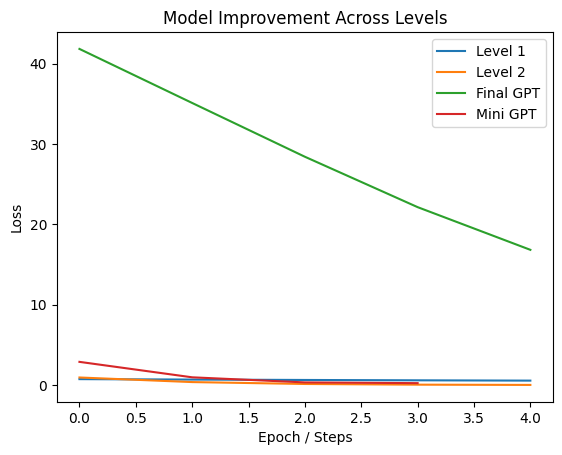

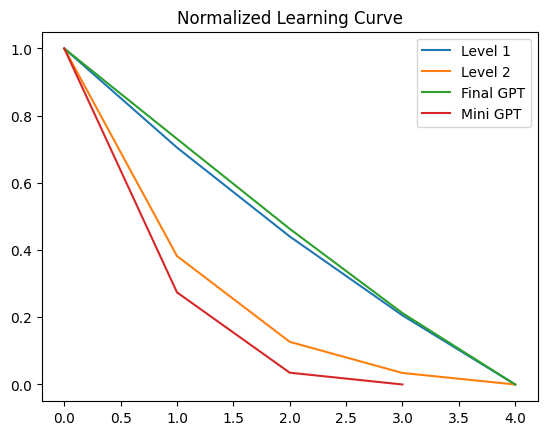

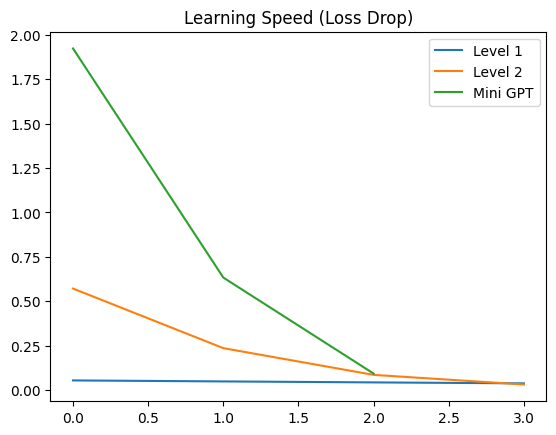


Generated Text Analysis:
Length: 31
Unique characters: 13


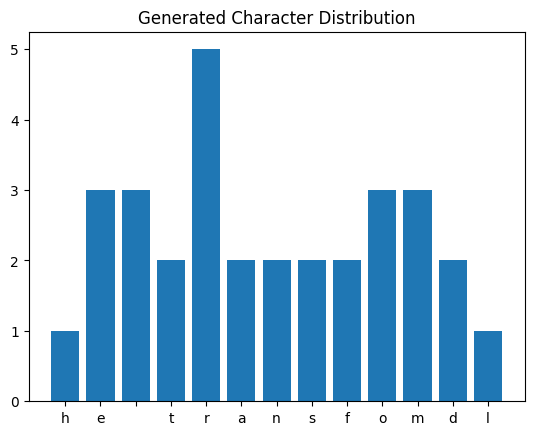

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# LOSS COMPARISON
# -------------------------------
plt.figure()
plt.plot(lvl1, label="Level 1")
plt.plot(lvl2, label="Level 2")
plt.plot(final_lvl, label="Final GPT")
plt.plot(best_lvl, label="Mini GPT")

plt.xlabel("Epoch / Steps")
plt.ylabel("Loss")
plt.title("Model Improvement Across Levels")
plt.legend()
plt.show()


# -------------------------------
# NORMALIZED COMPARISON
# -------------------------------
def normalize(x):
    return (np.array(x) - min(x)) / (max(x) - min(x))

plt.figure()
plt.plot(normalize(lvl1), label="Level 1")
plt.plot(normalize(lvl2), label="Level 2")
plt.plot(normalize(final_lvl), label="Final GPT")
plt.plot(normalize(best_lvl), label="Mini GPT")

plt.title("Normalized Learning Curve")
plt.legend()
plt.show()


# -------------------------------
# LEARNING SPEED
# -------------------------------
def slope(loss):
    return [loss[i] - loss[i+1] for i in range(len(loss)-1)]

plt.figure()
plt.plot(slope(lvl1), label="Level 1")
plt.plot(slope(lvl2), label="Level 2")
plt.plot(slope(best_lvl), label="Mini GPT")

plt.title("Learning Speed (Loss Drop)")
plt.legend()
plt.show()


# -------------------------------
# TEXT ANALYSIS
# -------------------------------
text = "he transformer modeld transform"

print("\nGenerated Text Analysis:")
print("Length:", len(text))
print("Unique characters:", len(set(text)))


# -------------------------------
# TOKEN DISTRIBUTION
# -------------------------------
from collections import Counter

counts = Counter(text)

plt.figure()
plt.bar(counts.keys(), counts.values())
plt.title("Generated Character Distribution")
plt.show()

In [15]:
# -------------------------------
# CLEAN TRAINING + AUTO LOSS TRACK
# -------------------------------

loss_history = []

model.train()

for epoch in range(5):

    # 🔥 Get proper batch (IMPORTANT for GPT)
    xb, yb = get_batch(data)

    optimizer.zero_grad()

    # Forward pass (use targets for GPT model)
    logits, loss = model(xb, yb)

    # Backprop
    loss.backward()
    optimizer.step()

    # Store loss automatically
    loss_history.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.2005
Epoch 2, Loss: 0.2561
Epoch 3, Loss: 0.2344
Epoch 4, Loss: 0.3010
Epoch 5, Loss: 0.1822


In [16]:
lvl_gpt = loss_history

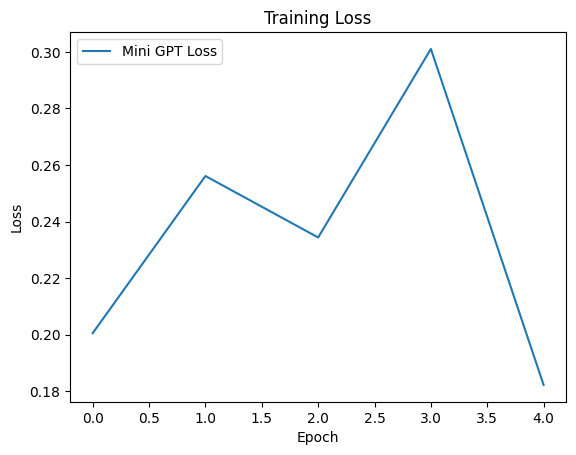

In [17]:
import matplotlib.pyplot as plt

plt.plot(lvl_gpt, label="Mini GPT Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

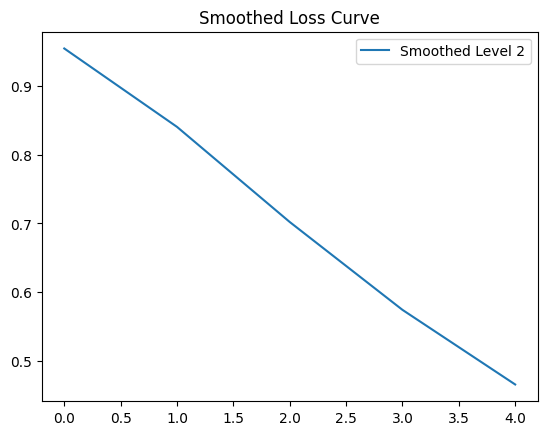

In [18]:
#SMOOTHED LOSS
def smooth(loss, factor=0.8):
    smoothed = []
    for l in loss:
        if smoothed:
            smoothed.append(smoothed[-1]*factor + l*(1-factor))
        else:
            smoothed.append(l)
    return smoothed

plt.figure()
plt.plot(smooth(lvl2), label="Smoothed Level 2")
plt.title("Smoothed Loss Curve")
plt.legend()
plt.show()

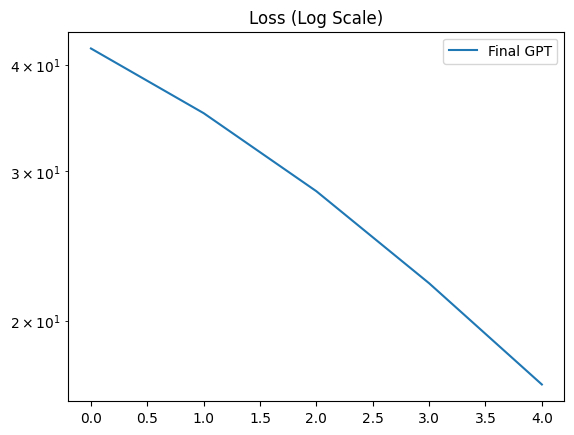

In [19]:
#LOG SCALE PLOT
plt.figure()
plt.plot(final_lvl, label="Final GPT")
plt.yscale("log")  # 🔥 important
plt.title("Loss (Log Scale)")
plt.legend()
plt.show()

In [21]:
#PERPLEXITY
import numpy as np

def perplexity(loss):
    return np.exp(loss)

print("Perplexity (Mini GPT):", perplexity(best_lvl[-1]))

Perplexity (Mini GPT): 1.2845391295901476


In [23]:
#MULTIPLE GENERATIONS
for _ in range(5):
    start = torch.tensor([[stoi['h']]])
    generated = model.generate(start, max_new_tokens=30)
    print(decode(generated[0].tolist()))
    print("-"*30)

his is ara eldis s this is a si
------------------------------
his is is a simple transformer 
------------------------------
his is a sis a simple transform
------------------------------
his is a simple transformer mod
------------------------------
his is a simple transformer mod
------------------------------


In [24]:
#TEMPERATURE EXPERIMENT
for temp in [0.5, 1.0, 1.5]:
    print(f"\nTemperature: {temp}")
    start = torch.tensor([[stoi['h']]])
    generated = model.generate(start, max_new_tokens=30, temperature=temp)
    print(decode(generated[0].tolist()))


Temperature: 0.5
his is is is a simple transform

Temperature: 1.0
h is is a simple transformer mo

Temperature: 1.5
hiworld orld thssformeldwerlld 


In [25]:
#TRAINING STABILITY CHECK
import numpy as np

print("Loss variance:", np.var(best_lvl))

Loss variance: 1.135950546875
